# Seasonal Agriculture Performance Analysis

### Major Project — VOIS AICTE Batch 1 (2026–2027)

**Domain:** Agriculture Data Analytics  
**Project Focus:** Analysis of Seasonal Agricultural Performance

---

**Student Name:** Radheshyam Suthar  
**College:** Indira Gandhi National Tribal University   
**AICTE STU ID:** STU69c4bfbbd70d51774501819

---

### Project Overview

This project analyzes agricultural data across different seasons to identify meaningful patterns, trends, relationships, and variations in agricultural performance.

The analysis focuses on seasonal differences in crop production, yield, resource utilization, environmental conditions, economic outcomes, and disease/pest risk using data analytics and statistical techniques.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed under different seasonal conditions.

The problem addressed in this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

## 2. Project Objectives

The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships, and differences in agricultural performance.

### Specific Objectives

1. Explore and understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Examine how agricultural performance varies across seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between seasonal conditions and agricultural outcomes.
6. Compare relevant agricultural groups across different seasons.
7. Identify significant differences and unusual patterns.
8. Apply appropriate statistical and data visualization techniques.
9. Interpret findings based on evidence from the dataset.
10. Develop meaningful conclusions and data-driven recommendations.

In [1]:
# ============================================================
# 3. Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# 4. Load Dataset
# ============================================================


file_url = "https://raw.githubusercontent.com/Radhe-jangir/seasonal-agriculture-performance/main/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_url)

print("Dataset loaded successfully from GitHub.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

assert df.shape == (4000, 28), "Dataset shape is not as expected."

print("Dataset verification: PASSED")

Dataset loaded successfully from GitHub.
Rows: 4000
Columns: 28
Dataset verification: PASSED


## 5. Initial Data Understanding

The first step of the analysis is to understand the structure and contents of the dataset before performing cleaning or statistical analysis.

In [3]:
# Display the first five records
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Dataset dimensions
print("Dataset Shape:", df.shape)
print("Number of Records:", df.shape[0])
print("Number of Variables:", df.shape[1])

Dataset Shape: (4000, 28)
Number of Records: 4000
Number of Variables: 28


In [5]:
# Display all column names
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
# Descriptive statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [8]:
# Summary of categorical variables
df.describe(include="object").T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [9]:
# Display a random sample of records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,Flood,228.2,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,Drip,65.9,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,Drip,143.0,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,Rainfed,116.4,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,Flood,242.8,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


## 6. Data Quality Analysis

Before performing detailed analysis, the dataset is assessed for missing values, duplicate records, inconsistent data types, and categorical variations.

This step helps ensure that the dataset is reliable and suitable for subsequent exploratory and statistical analysis.

In [10]:
# ============================================================
# 6.1 Missing Value Analysis
# ============================================================

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


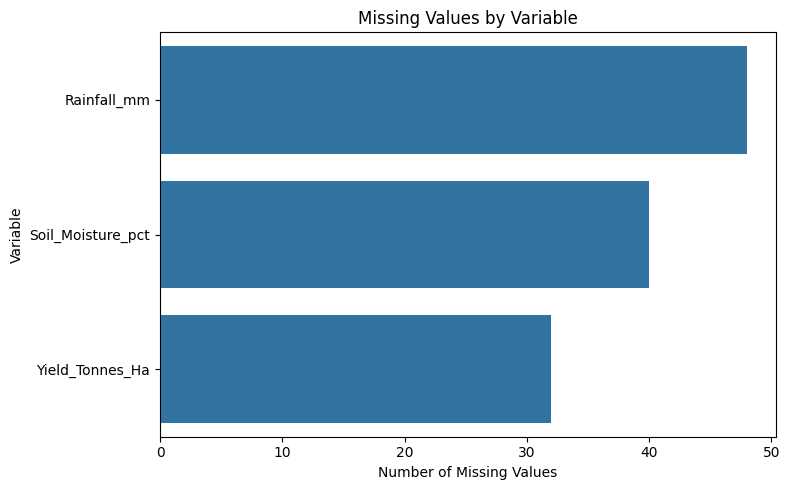

In [11]:
# Visualize missing values

plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_summary["Missing Values"],
    y=missing_summary.index
)

plt.title("Missing Values by Variable")
plt.xlabel("Number of Missing Values")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 6.2 Duplicate Record Analysis
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
# ============================================================
# 6.3 Categorical Variable Review
# ============================================================

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print("Unique values:", df[column].nunique())
    print(df[column].unique())


Farm_ID
-------
Unique values: 4000
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
-----
Unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
--------
Unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
----
Unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
------
Unique values: 3
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
-----------------
Unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### Missing Data Treatment Strategy

The missing-value analysis identified incomplete observations in selected numerical variables. Instead of replacing missing values with arbitrary constants, the missing observations will be handled using statistically appropriate methods.

For numerical variables, median imputation will be considered where appropriate because the dataset contains variables with potentially skewed distributions and extreme observations.

The treatment will be applied only after examining the distribution of the affected variables.

In [14]:
# ============================================================
# 6.4 Distribution of Variables with Missing Values
# ============================================================

missing_columns = missing_summary.index.tolist()

df[missing_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,3952.0,601.152657,288.925025,80.0,370.20,582.00,834.95,1395.20
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.0,21.70,26.40,31.30,47.00
Yield_Tonnes_Ha,3968.0,5.270595,13.361398,0.3,1.05,1.74,2.84,101.44


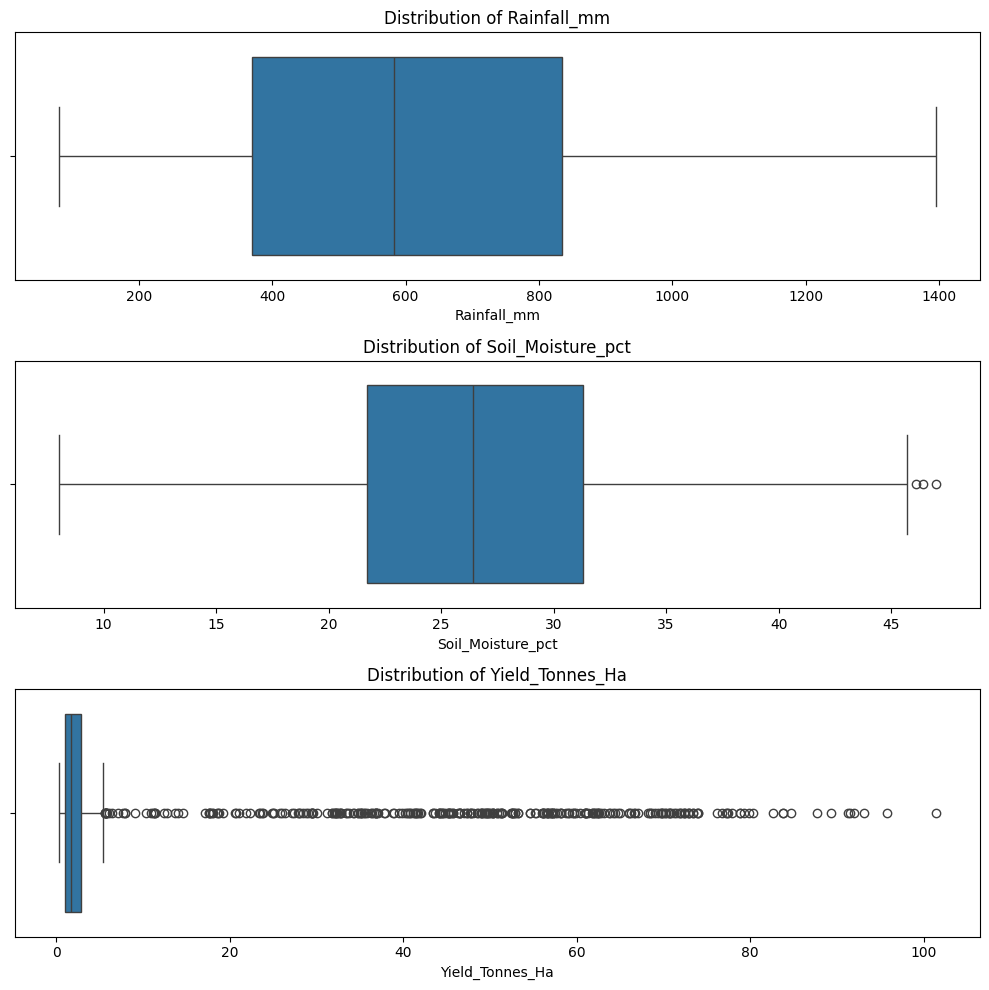

In [15]:
# Boxplots for variables containing missing values

fig, axes = plt.subplots(
    nrows=len(missing_columns),
    ncols=1,
    figsize=(10, 10)
)

for ax, column in zip(axes, missing_columns):
    sns.boxplot(x=df[column], ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

## 7. Data Cleaning and Preparation

Based on the data-quality assessment, missing values were identified in three numerical variables: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`.

The missing proportion is relatively small in each variable. Since the affected variables show different levels of spread and the yield variable contains extreme observations, median imputation is used to reduce the influence of skewed values on the imputed observations.

Duplicate records were also checked and none were found.

Extreme observations are retained because they may represent genuine agricultural conditions rather than data-entry errors. Their influence will be considered during subsequent analysis.

In [16]:
# ============================================================
# 7.1 Create Clean Dataset
# ============================================================

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original dataset shape: (4000, 28)
Working dataset shape: (4000, 28)


In [17]:
# ============================================================
# 7.2 Handle Missing Numerical Values
# ============================================================

imputation_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

imputation_values = {}

for column in imputation_columns:
    median_value = df_clean[column].median()
    imputation_values[column] = median_value
    df_clean[column] = df_clean[column].fillna(median_value)

print("Median values used for imputation:")
for column, value in imputation_values.items():
    print(f"{column}: {value:.2f}")

Median values used for imputation:
Rainfall_mm: 582.00
Soil_Moisture_pct: 26.40
Yield_Tonnes_Ha: 1.74


In [18]:
# ============================================================
# 7.3 Verify Missing Values After Imputation
# ============================================================

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if remaining_missing.empty:
    print("No missing values remain in the cleaned dataset.")
else:
    print("Remaining missing values:")
    print(remaining_missing)

No missing values remain in the cleaned dataset.


In [19]:
# ============================================================
# 7.4 Verify Duplicate Records
# ============================================================

duplicate_count_clean = df_clean.duplicated().sum()

print("Duplicate rows after cleaning:", duplicate_count_clean)

Duplicate rows after cleaning: 0


In [20]:
# ============================================================
# 7.5 Before and After Data Quality Comparison
# ============================================================

quality_comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Total Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "After Cleaning": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

quality_comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,4000,4000
1,Columns,28,28
2,Total Missing Values,120,0
3,Duplicate Rows,0,0


In [21]:
# ============================================================
# 7.6 Final Clean Dataset Information
# ============================================================

print("Final cleaned dataset:")
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")

Final cleaned dataset:
Rows: 4000
Columns: 28
Missing values: 0
Duplicate rows: 0


### Data Cleaning Summary

The dataset initially contained 120 missing values across three numerical variables: rainfall, soil moisture, and yield. These represented a small proportion of the total 4,000 observations.

Median imputation was applied to the affected numerical variables. This approach was selected because it is less sensitive to extreme observations than mean imputation.

The dataset contained no duplicate rows, so no duplicate records were removed.

After cleaning, the dataset retained all 4,000 observations and 28 variables, with no remaining missing values or duplicate rows.

## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of agricultural observations and identify patterns across seasons, crops, environmental conditions, resource utilization, and economic outcomes.

The cleaned dataset `df_clean` is used for all subsequent analysis.

In [22]:
# ============================================================
# 8.1 Distribution of Records Across Seasons
# ============================================================

season_counts = df_clean["Season"].value_counts()

print("Number of records by season:")
print(season_counts)

Number of records by season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


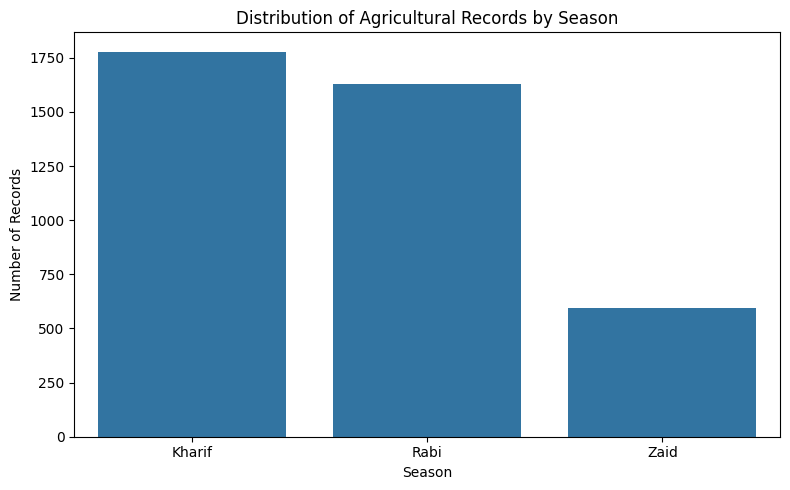

In [23]:
# Visualize number of records by season

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Season",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 8.2 Distribution of Crops
# ============================================================

crop_counts = df_clean["Crop"].value_counts()

print("Number of records by crop:")
print(crop_counts)

Number of records by crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


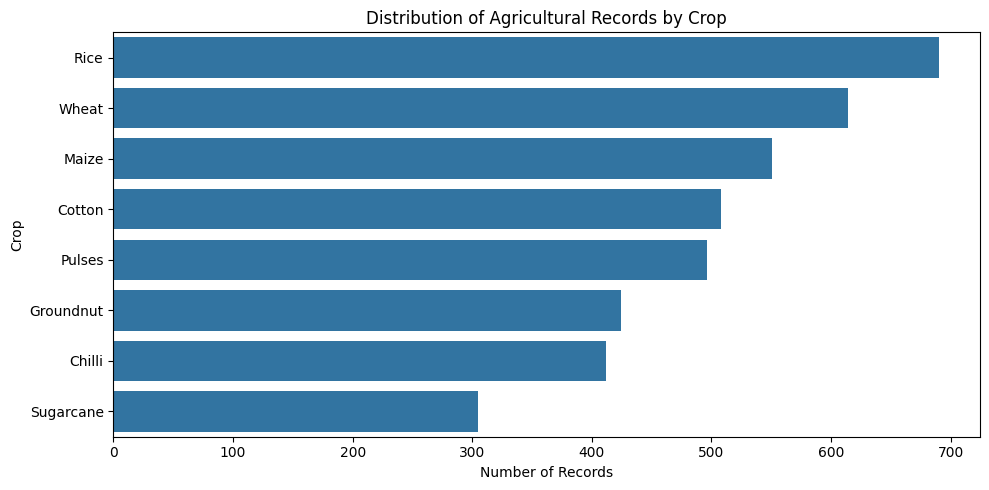

In [25]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    y="Crop",
    order=df_clean["Crop"].value_counts().index
)

plt.title("Distribution of Agricultural Records by Crop")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 8.3 Seasonal Yield Analysis
# ============================================================

seasonal_yield = (
    df_clean
    .groupby("Season")["Yield_Tonnes_Ha"]
    .agg(["count", "mean", "median", "std"])
    .reindex(["Kharif", "Rabi", "Zaid"])
)

seasonal_yield

,count,mean,median,std
Season,,,,
Kharif,1779,5.628612,1.94,14.392742
Rabi,1627,5.039435,1.67,12.751545
Zaid,594,4.641313,1.46,11.273088


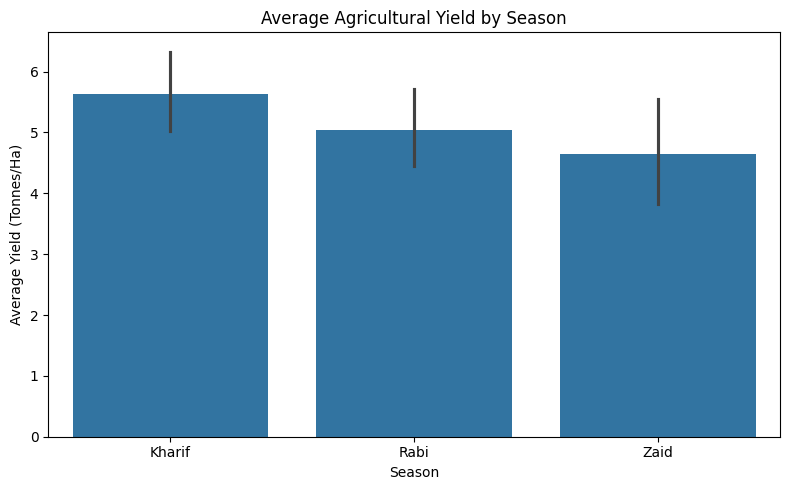

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

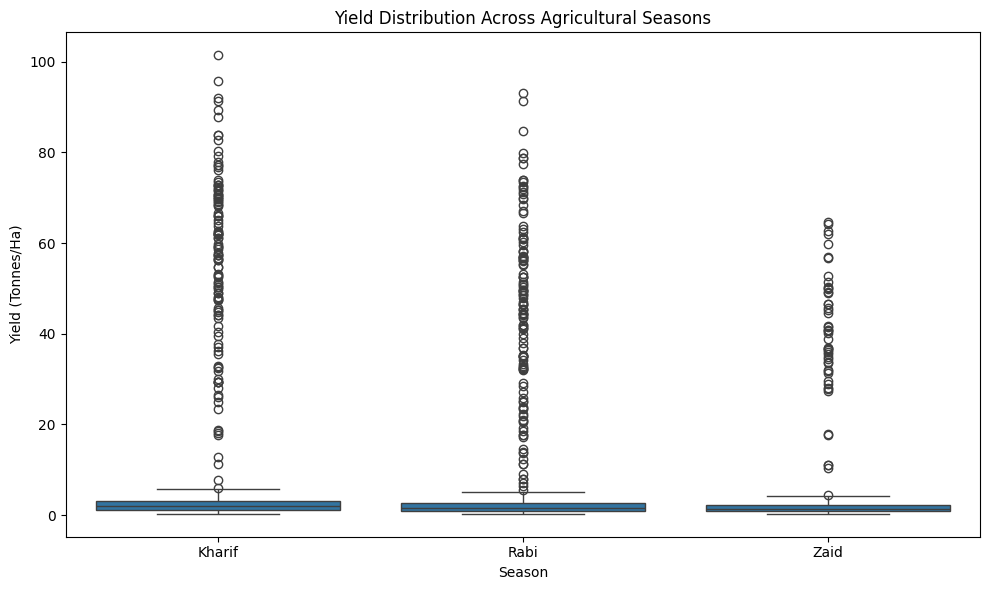

In [28]:
# ============================================================
# 8.4 Yield Distribution Across Seasons
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Yield Distribution Across Agricultural Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [29]:
# Median yield by season

median_yield = (
    df_clean
    .groupby("Season")["Yield_Tonnes_Ha"]
    .median()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

print("Median Yield by Season:")
print(median_yield)

Median Yield by Season:
Season
Kharif    1.94
Rabi      1.67
Zaid      1.46
Name: Yield_Tonnes_Ha, dtype: float64


In [30]:
# Compare mean and median yield across seasons

yield_comparison = (
    df_clean
    .groupby("Season")["Yield_Tonnes_Ha"]
    .agg(
        Mean_Yield="mean",
        Median_Yield="median",
        Minimum_Yield="min",
        Maximum_Yield="max"
    )
    .reindex(["Kharif", "Rabi", "Zaid"])
)

yield_comparison.round(2)

,Mean_Yield,Median_Yield,Minimum_Yield,Maximum_Yield
Season,,,,
Kharif,5.63,1.94,0.3,101.44
Rabi,5.04,1.67,0.3,93.13
Zaid,4.64,1.46,0.3,64.76


In [31]:
# ============================================================
# 8.7 Seasonal Profit Analysis
# ============================================================

seasonal_profit = (
    df_clean
    .groupby("Season")["Profit_INR"]
    .agg(["count", "mean", "median", "std"])
    .reindex(["Kharif", "Rabi", "Zaid"])
)

seasonal_profit.round(2)

,count,mean,median,std
Season,,,,
Kharif,1779,178914.65,38808.0,611549.78
Rabi,1627,87689.47,-3187.0,489901.25
Zaid,594,-24804.82,-62144.0,436356.75


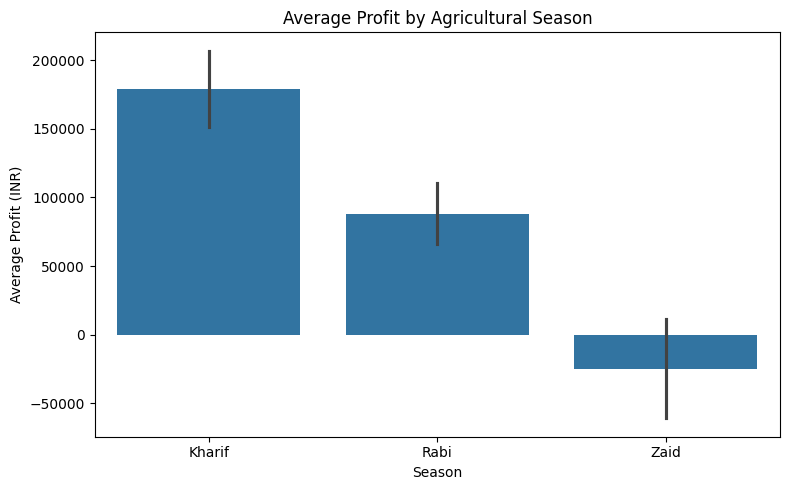

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.title("Average Profit by Agricultural Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 8.8 Water Usage Across Seasons
# ============================================================

seasonal_water = (
    df_clean
    .groupby("Season")["Water_Used_m3"]
    .agg(["mean", "median", "std"])
    .reindex(["Kharif", "Rabi", "Zaid"])
)

seasonal_water.round(2)

,mean,median,std
Season,,,
Kharif,6102.20,4469.0,5670.58
Rabi,5846.99,4292.0,5397.65
Zaid,6419.89,4805.0,5734.62


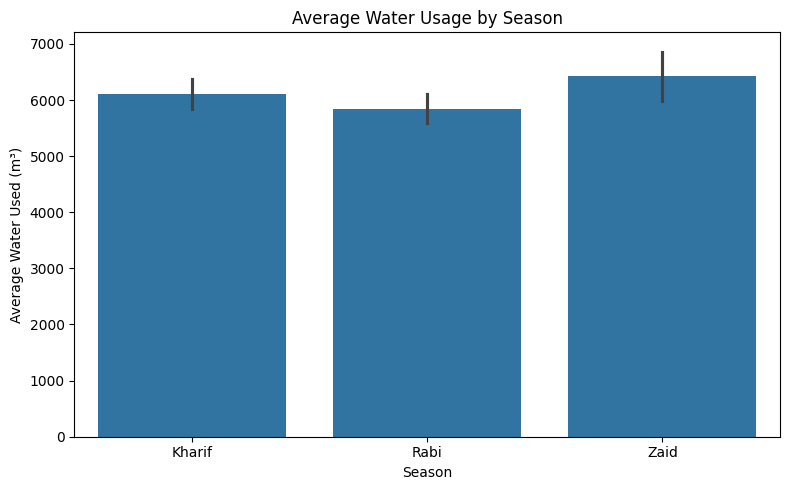

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Water_Used_m3",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 8.9 Water Efficiency Across Seasons
# ============================================================

seasonal_efficiency = (
    df_clean
    .groupby("Season")["Water_Efficiency_t_per_1000m3"]
    .agg(["mean", "median", "std"])
    .reindex(["Kharif", "Rabi", "Zaid"])
)

seasonal_efficiency.round(3)

,mean,median,std
Season,,,
Kharif,5.892,3.277,9.833
Rabi,5.186,2.740,8.258
Zaid,4.413,2.302,6.930


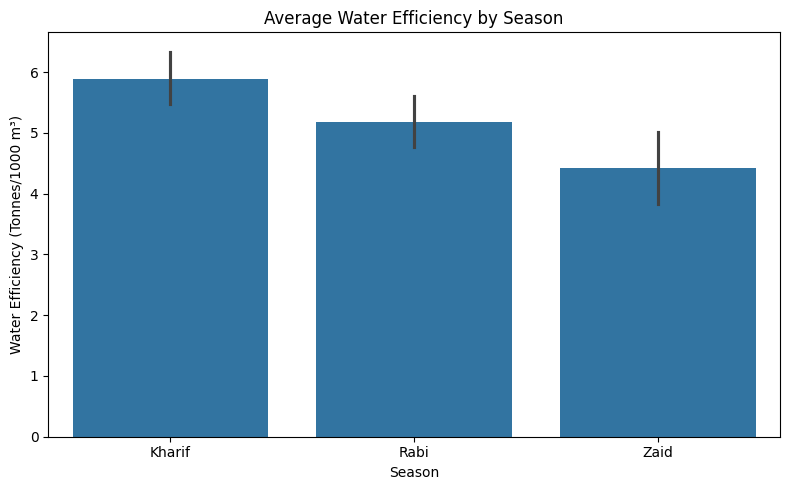

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes/1000 m³)")
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# 8.10 Environmental Conditions by Season
# ============================================================

environmental_summary = (
    df_clean
    .groupby("Season")[
        [
            "Rainfall_mm",
            "Avg_Temperature_C",
            "Humidity_pct",
            "Sunlight_Hours_Day",
            "Soil_Moisture_pct"
        ]
    ]
    .mean()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

environmental_summary.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


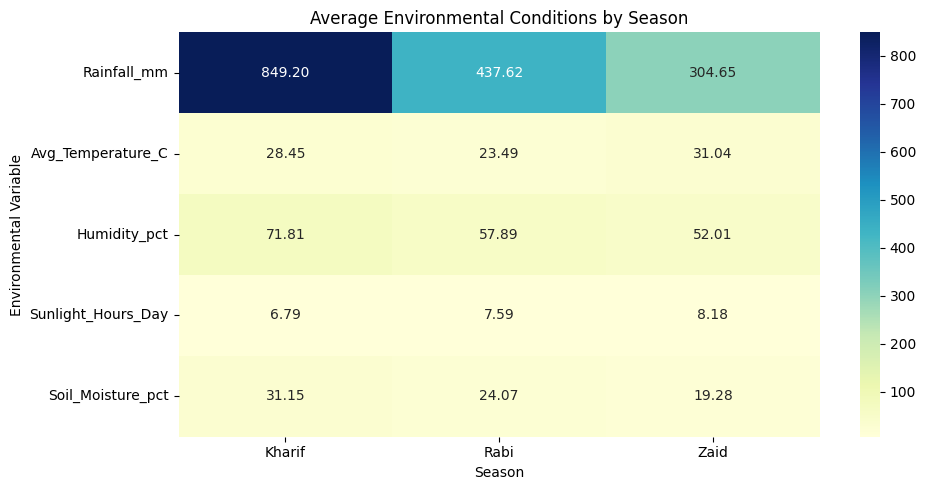

In [38]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    environmental_summary.T,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Environmental Conditions by Season")
plt.xlabel("Season")
plt.ylabel("Environmental Variable")
plt.tight_layout()
plt.show()

### Initial EDA Observations

The exploratory analysis provides an initial understanding of how agricultural conditions and performance vary across seasons.

Key areas examined include:

- Distribution of observations across seasons.
- Distribution of crops within the dataset.
- Seasonal differences in yield.
- Seasonal differences in profitability.
- Water usage and water-use efficiency.
- Differences in rainfall, temperature, humidity, sunlight, and soil moisture.

The numerical results and visualizations will be interpreted together to identify the major seasonal patterns and relationships present in the dataset.

## 9. Crop × Season Performance Analysis

Seasonal performance can vary considerably across different crops. Therefore, crop-level analysis is performed to identify combinations of crops and seasons associated with higher yield, profitability, and water-use efficiency.

This analysis uses grouped summaries of yield, profit, and water efficiency for each Crop–Season combination.

In [39]:
# ============================================================
# 9.1 Crop × Season Yield Analysis
# ============================================================

crop_season_yield = (
    df_clean
    .groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
    .agg(["count", "mean", "median"])
    .round(2)
)

crop_season_yield

count   mean  median
Crop      Season                      
Chilli    Kharif    185   1.73    1.77
          Rabi      163   1.47    1.58
          Zaid       64   1.20    1.25
Cotton    Kharif    215   1.37    1.45
          Rabi      201   1.20    1.21
          Zaid       92   0.96    0.98
Groundnut Kharif    193   1.48    1.52
          Rabi      177   1.23    1.31
          Zaid       54   1.04    1.10
Maize     Kharif    234   2.97    3.12
          Rabi      233   2.60    2.78
          Zaid       84   2.29    2.26
Pulses    Kharif    221   1.04    1.09
          Rabi      213   0.88    0.90
          Zaid       62   0.67    0.68
Rice      Kharif    314   2.70    2.86
          Rabi      274   2.32    2.37
          Zaid      102   1.90    1.94
Sugarcane Kharif    125  53.46   56.65
          Rabi      129  43.29   45.21
          Zaid       51  38.42   38.78
Wheat     Kharif    292   2.25    2.36
          Rabi      237   2.06    2.22
          Zaid       85   1.75    1.84

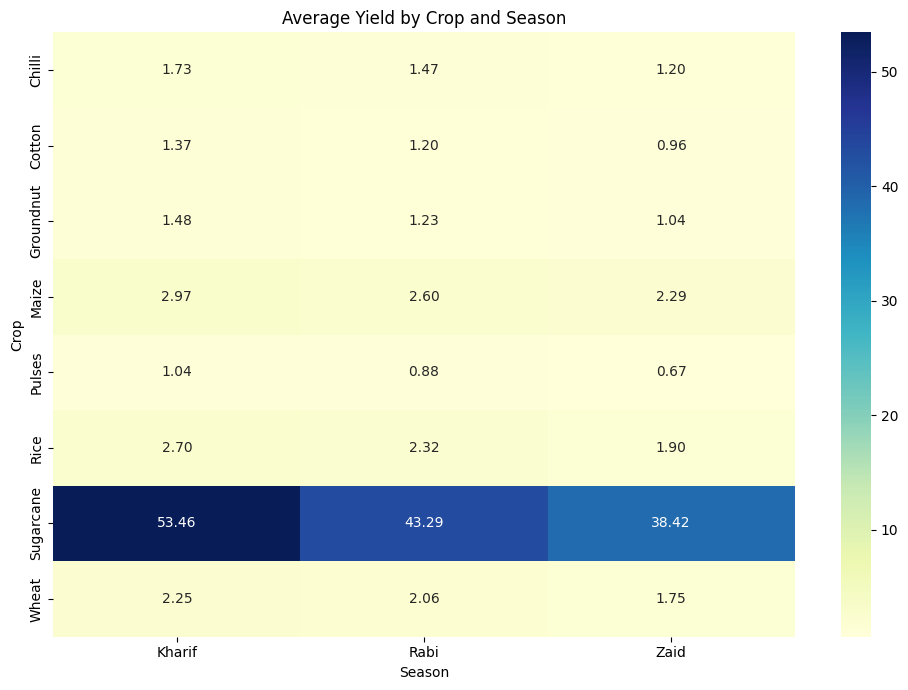

In [40]:
# Mean yield heatmap: Crop × Season

yield_pivot = (
    df_clean
    .pivot_table(
        index="Crop",
        columns="Season",
        values="Yield_Tonnes_Ha",
        aggfunc="mean"
    )
    .reindex(columns=["Kharif", "Rabi", "Zaid"])
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    yield_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# 9.2 Crop × Season Profit Analysis
# ============================================================

crop_season_profit = (
    df_clean
    .groupby(["Crop", "Season"])["Profit_INR"]
    .agg(["count", "mean", "median"])
    .round(2)
)

crop_season_profit

count        mean    median
Crop      Season                             
Chilli    Kharif    185   954380.42  705116.0
          Rabi      163   638572.50  470004.0
          Zaid       64   448659.09  350401.0
Cotton    Kharif    215   216999.55  136193.0
          Rabi      201   107343.59   50603.0
          Zaid       92   -53925.34  -11434.5
Groundnut Kharif    193   108265.44   87406.0
          Rabi      177    10416.54   24517.0
          Zaid       54   -68872.50  -38896.5
Maize     Kharif    234   -39332.67   -9883.5
          Rabi      233   -89133.40  -45813.0
          Zaid       84  -194049.17 -147455.5
Pulses    Kharif    221    43338.90   57156.0
          Rabi      213   -14309.14  -11734.0
          Zaid       62  -139227.81 -128893.0
Rice      Kharif    314   -64903.40  -39903.5
          Rabi      274   -98427.87  -49931.5
          Zaid      102  -227239.34 -183631.5
Sugarcane Kharif    125  1000790.81  940895.0
          Rabi      129   731612.86  622229.0
          Zaid       51   583635.80  556627.0
Wheat     Kharif    292  -105871.87  -57248.5
          Rabi      237  -119954.57  -76084.0
          Zaid       85  -193208.95 -125778.0

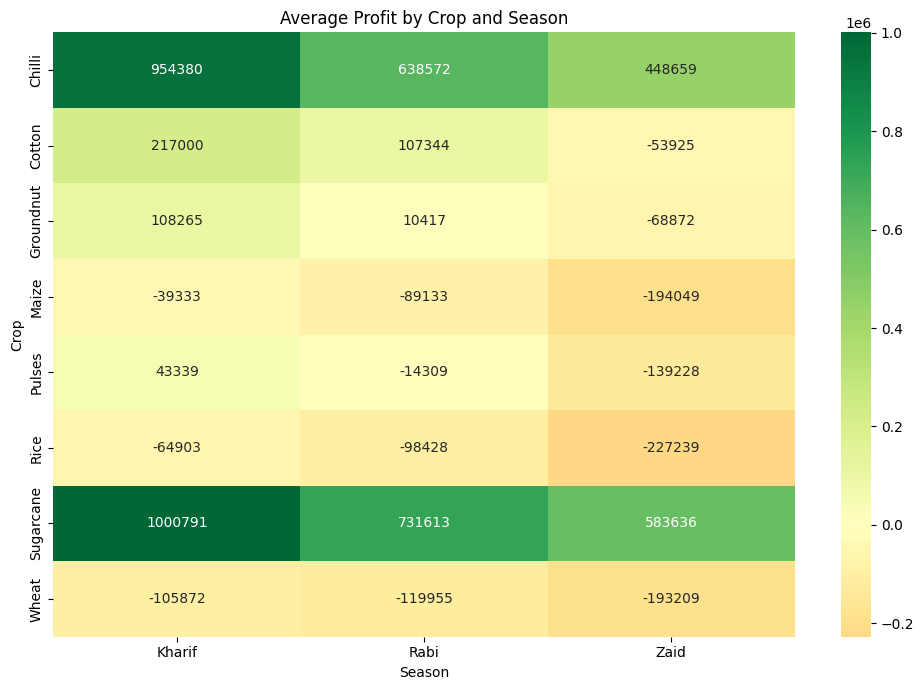

In [42]:
profit_pivot = (
    df_clean
    .pivot_table(
        index="Crop",
        columns="Season",
        values="Profit_INR",
        aggfunc="mean"
    )
    .reindex(columns=["Kharif", "Rabi", "Zaid"])
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    profit_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# 9.3 Crop × Season Water Efficiency
# ============================================================

crop_season_efficiency = (
    df_clean
    .groupby(["Crop", "Season"])["Water_Efficiency_t_per_1000m3"]
    .agg(["count", "mean", "median"])
    .round(3)
)

crop_season_efficiency

count    mean  median
Crop      Season                       
Chilli    Kharif    185   3.260   3.224
          Rabi      163   2.886   2.560
          Zaid       64   2.204   1.955
Cotton    Kharif    215   2.131   1.858
          Rabi      201   1.938   1.801
          Zaid       92   1.489   1.235
Groundnut Kharif    193   3.584   3.128
          Rabi      177   2.897   2.500
          Zaid       54   2.465   2.254
Maize     Kharif    234   6.055   5.710
          Rabi      233   5.458   5.061
          Zaid       84   4.746   4.576
Pulses    Kharif    221   3.352   3.189
          Rabi      213   2.699   2.443
          Zaid       62   1.950   2.009
Rice      Kharif    314   2.169   2.062
          Rabi      274   1.844   1.646
          Zaid      102   1.533   1.334
Sugarcane Kharif    125  36.004  33.854
          Rabi      129  27.925  26.144
          Zaid       51  23.391  22.171
Wheat     Kharif    292   4.758   4.332
          Rabi      237   4.687   4.362
          Zaid       85   4.017   3.839

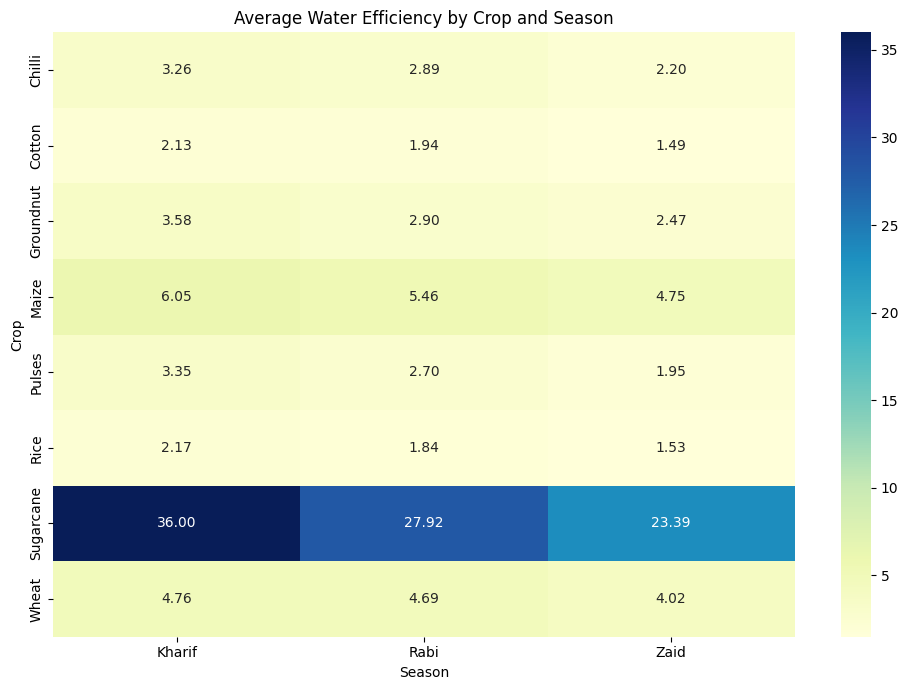

In [44]:
efficiency_pivot = (
    df_clean
    .pivot_table(
        index="Crop",
        columns="Season",
        values="Water_Efficiency_t_per_1000m3",
        aggfunc="mean"
    )
    .reindex(columns=["Kharif", "Rabi", "Zaid"])
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    efficiency_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Water Efficiency by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

Correlation analysis is performed to examine the relationships between environmental conditions, resource utilization, agricultural yield, water efficiency, and profitability.

The analysis helps identify variables that show stronger positive or negative associations with agricultural performance.

In [45]:
# ============================================================
# 10.1 Correlation Analysis
# ============================================================

correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

correlation_matrix = (
    df_clean[correlation_columns]
    .corr()
    .round(3)
)

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.000,0.198,0.521,-0.363,0.509,0.002,0.058,0.031,0.108
Avg_Temperature_C,0.198,1.000,0.138,-0.034,0.084,0.023,0.007,0.010,0.009
Humidity_pct,0.521,0.138,1.000,-0.297,0.446,-0.002,0.026,0.012,0.064
Sunlight_Hours_Day,-0.363,-0.034,-0.297,1.000,-0.303,-0.006,-0.021,-0.015,-0.055
Soil_Moisture_pct,0.509,0.084,0.446,-0.303,1.000,0.003,0.028,0.011,0.091
Water_Used_m3,0.002,0.023,-0.002,-0.006,0.003,1.000,0.217,0.386,0.190
Water_Efficiency_t_per_1000m3,0.058,0.007,0.026,-0.021,0.028,0.217,1.000,0.913,0.489
Yield_Tonnes_Ha,0.031,0.010,0.012,-0.015,0.011,0.386,0.913,1.000,0.488
Profit_INR,0.108,0.009,0.064,-0.055,0.091,0.190,0.489,0.488,1.000


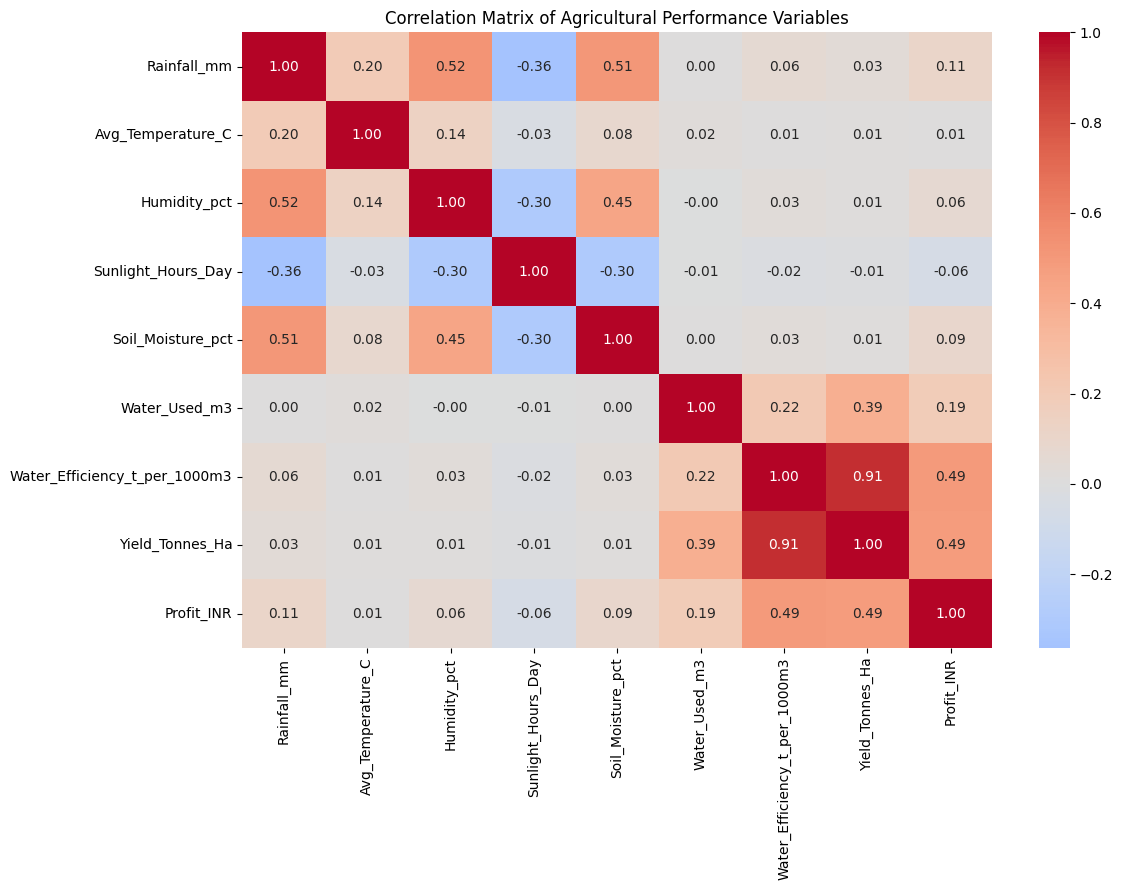

In [46]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Performance Variables")
plt.tight_layout()
plt.show()

## 11. Statistical Significance Testing

Correlation coefficients describe the strength and direction of linear relationships between variables. Statistical significance testing is performed to determine whether the observed relationships are unlikely to have occurred by random variation alone.

Pearson correlation tests are used to evaluate the statistical significance of selected relationships identified during the correlation analysis.

In [47]:
# ============================================================
# 11.1 Pearson Correlation Significance Tests
# ============================================================

from scipy.stats import pearsonr

tests = [
    ("Water Used vs Yield", "Water_Used_m3", "Yield_Tonnes_Ha"),
    ("Yield vs Profit", "Yield_Tonnes_Ha", "Profit_INR"),
    ("Water Efficiency vs Profit", "Water_Efficiency_t_per_1000m3", "Profit_INR"),
    ("Rainfall vs Yield", "Rainfall_mm", "Yield_Tonnes_Ha"),
    ("Soil Moisture vs Yield", "Soil_Moisture_pct", "Yield_Tonnes_Ha")
]

results = []

for name, x, y in tests:
    r, p = pearsonr(
        df_clean[x].dropna(),
        df_clean.loc[df_clean[x].notna(), y]
    )

    results.append({
        "Relationship": name,
        "Pearson_r": round(r, 3),
        "p_value": p,
        "Significant_at_0.05": p < 0.05
    })

correlation_significance = pd.DataFrame(results)

correlation_significance

,Relationship,Pearson_r,p_value,Significant_at_0.05
0,Water Used vs Yield,0.386,1.641403e-142,True
1,Yield vs Profit,0.488,5.713938e-239,True
2,Water Efficiency vs Profit,0.489,4.135920e-240,True
3,Rainfall vs Yield,0.031,5.030401e-02,False
4,Soil Moisture vs Yield,0.011,4.867650e-01,False


In [48]:
correlation_significance["p_value"] = (
    correlation_significance["p_value"]
    .apply(lambda x: f"{x:.6e}")
)

correlation_significance

,Relationship,Pearson_r,p_value,Significant_at_0.05
0,Water Used vs Yield,0.386,1.641403e-142,True
1,Yield vs Profit,0.488,5.713938e-239,True
2,Water Efficiency vs Profit,0.489,4.135920e-240,True
3,Rainfall vs Yield,0.031,5.030401e-02,False
4,Soil Moisture vs Yield,0.011,4.867650e-01,False


## 12. Statistical Comparison of Agricultural Yield Across Seasons

The exploratory analysis showed differences in average agricultural yield across Kharif, Rabi, and Zaid seasons.

One-way Analysis of Variance (ANOVA) is performed to determine whether the mean yield differs significantly across the three agricultural seasons.

The null hypothesis (H₀) states that the mean yield is equal across all seasons.

The alternative hypothesis (H₁) states that at least one season has a different mean yield.

In [49]:
# ============================================================
# 12.1 One-Way ANOVA: Yield Across Seasons
# ============================================================

from scipy.stats import f_oneway

# Separate yield values by season
kharif_yield = df_clean.loc[
    df_clean["Season"] == "Kharif", "Yield_Tonnes_Ha"
].dropna()

rabi_yield = df_clean.loc[
    df_clean["Season"] == "Rabi", "Yield_Tonnes_Ha"
].dropna()

zaid_yield = df_clean.loc[
    df_clean["Season"] == "Zaid", "Yield_Tonnes_Ha"
].dropna()

# Perform one-way ANOVA
f_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("One-Way ANOVA: Yield Across Seasons")
print("-" * 45)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6e}")

if p_value < 0.05:
    print("Result: Significant difference exists between seasonal mean yields.")
else:
    print("Result: No statistically significant difference between seasonal mean yields.")

One-Way ANOVA: Yield Across Seasons
---------------------------------------------
F-statistic: 1.5439
P-value: 2.136781e-01
Result: No statistically significant difference between seasonal mean yields.


In [50]:
# ============================================================
# 12.2 ANOVA Summary
# ============================================================

anova_summary = pd.DataFrame({
    "Metric": [
        "Kharif Mean Yield",
        "Rabi Mean Yield",
        "Zaid Mean Yield",
        "F-statistic",
        "P-value",
        "Significance Level"
    ],
    "Value": [
        kharif_yield.mean(),
        rabi_yield.mean(),
        zaid_yield.mean(),
        f_stat,
        p_value,
        0.05
    ]
})

anova_summary["Value"] = anova_summary["Value"].round(4)

anova_summary

,Metric,Value
0,Kharif Mean Yield,5.6286
1,Rabi Mean Yield,5.0394
2,Zaid Mean Yield,4.6413
3,F-statistic,1.5439
4,P-value,0.2137
5,Significance Level,0.0500


### 12.3 Non-Parametric Validation Using Kruskal-Wallis Test

The yield distributions contain substantial variability and extreme observations. Therefore, the Kruskal-Wallis H-test is used as a non-parametric alternative to one-way ANOVA.

This test evaluates whether the distributions of agricultural yield differ significantly across Kharif, Rabi, and Zaid seasons without relying on the same normality assumptions as ANOVA.

In [51]:
# ============================================================
# 12.3 Kruskal-Wallis Test: Yield Across Seasons
# ============================================================

from scipy.stats import kruskal

h_stat, kw_p_value = kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("Kruskal-Wallis Test: Yield Across Seasons")
print("-" * 50)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {kw_p_value:.6e}")

if kw_p_value < 0.05:
    print("Result: Significant difference exists across seasonal yield distributions.")
else:
    print("Result: No statistically significant difference exists across seasonal yield distributions.")

Kruskal-Wallis Test: Yield Across Seasons
--------------------------------------------------
H-statistic: 68.7131
P-value: 1.199905e-15
Result: Significant difference exists across seasonal yield distributions.


### 12.4 Post-Hoc Analysis Using Tukey's HSD

When ANOVA indicates a statistically significant difference, Tukey's Honestly Significant Difference (HSD) test is used to identify which pairs of seasons differ significantly in their mean agricultural yield.

The test compares Kharif–Rabi, Kharif–Zaid, and Rabi–Zaid.

In [52]:
# ============================================================
# 12.4 Statistical Test Summary
# ============================================================

season_test_summary = pd.DataFrame({
    "Test": [
        "One-Way ANOVA",
        "Kruskal-Wallis"
    ],
    "Statistic": [
        f_stat,
        h_stat
    ],
    "P_Value": [
        p_value,
        kw_p_value
    ],
    "Significant_at_0.05": [
        p_value < 0.05,
        kw_p_value < 0.05
    ]
})

season_test_summary.round(4)

,Test,Statistic,P_Value,Significant_at_0.05
0,One-Way ANOVA,1.5439,0.2137,False
1,Kruskal-Wallis,68.7131,0.0000,True


### 12.5 Non-Parametric Validation Using Kruskal-Wallis Test

The yield distribution contains substantial variability and extreme observations. Therefore, the Kruskal-Wallis H-test is additionally performed as a non-parametric alternative to one-way ANOVA.

This provides a robustness check without relying as strongly on the normality assumption.

In [53]:
# ============================================================
# 12.5 Kruskal-Wallis Test
# ============================================================

from scipy.stats import kruskal

h_stat, kw_p_value = kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("Kruskal-Wallis Test: Yield Across Seasons")
print("-" * 50)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {kw_p_value:.6e}")

if kw_p_value < 0.05:
    print("Result: Seasonal yield differences are statistically significant.")
else:
    print("Result: No statistically significant seasonal difference was detected.")

Kruskal-Wallis Test: Yield Across Seasons
--------------------------------------------------
H-statistic: 68.7131
P-value: 1.199905e-15
Result: Seasonal yield differences are statistically significant.


### 12.6 Seasonal Statistical Test Interpretation

The seasonal yield analysis produced different results under parametric and non-parametric testing.

The one-way ANOVA resulted in an F-statistic of 1.5439 with a p-value of 0.2137, indicating that the difference in seasonal mean yields was not statistically significant at the 5% significance level.

However, the Kruskal-Wallis test produced an H-statistic of 68.7131 with a p-value of approximately 1.20 × 10⁻¹⁵. This indicates a statistically significant difference in the yield distributions across Kharif, Rabi, and Zaid seasons.

The difference between the two tests suggests that the seasonal yield distributions may contain substantial variability or non-normal characteristics. Therefore, the Kruskal-Wallis result provides an important robustness check and indicates that seasonal differences are statistically detectable when the analysis is based on the ranks of observations rather than only the means.

Overall, the analysis suggests that season is associated with differences in agricultural yield distributions, although the difference in seasonal means alone is not statistically significant under the one-way ANOVA.

## 13. Crop-wise Statistical Analysis

This section evaluates differences in agricultural yield across the major crop categories.

The analysis compares crop-level yield distributions and applies statistical testing to determine whether observed differences between crops are statistically significant.

In [54]:
# ============================================================
# 13.1 Crop-wise Yield Comparison
# ============================================================

crop_yield_summary = (
    df_clean.groupby("Crop")["Yield_Tonnes_Ha"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

crop_yield_summary.round(3)

,count,mean,median,std
Crop,,,,
Sugarcane,305,46.642,47.880,21.334
Maize,551,2.710,2.840,1.235
Rice,690,2.431,2.440,1.144
Wheat,614,2.108,2.215,0.914
Chilli,412,1.543,1.565,0.781
Groundnut,424,1.323,1.400,0.606
Cotton,508,1.230,1.255,0.525
Pulses,496,0.922,0.945,0.426


### 13.2 Crop-wise Yield Distribution

The following visualization compares the yield distributions of different crops. It helps identify differences in central tendency, variability, and potential outliers before performing statistical tests.

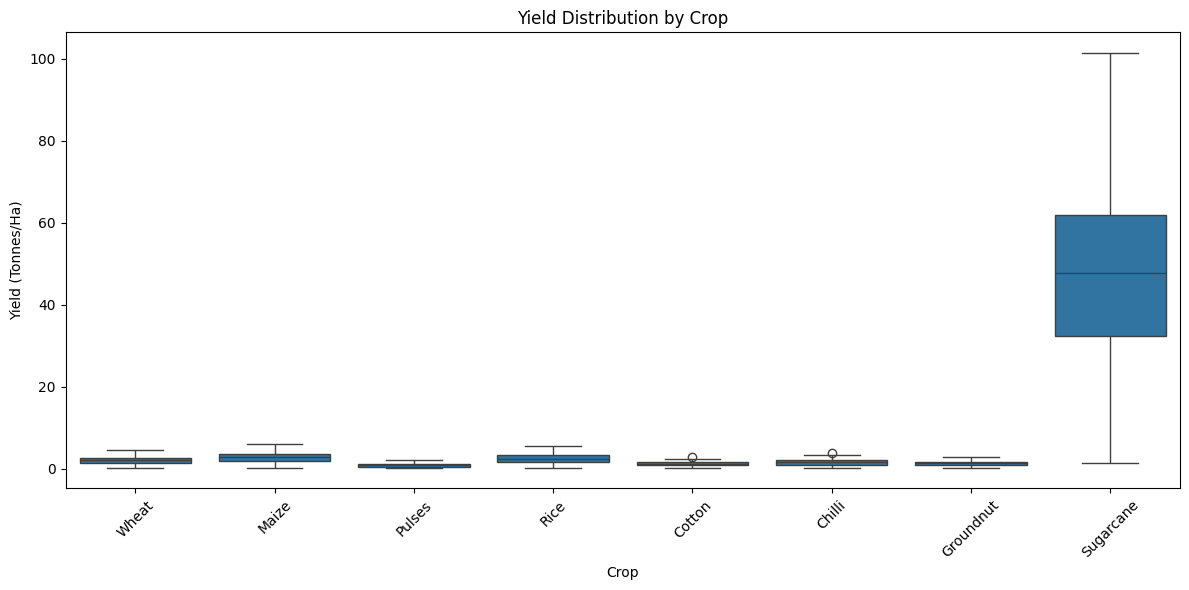

In [55]:
# ============================================================
# 13.2 Crop-wise Yield Distribution
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="Crop",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 13.3 One-Way ANOVA: Yield Across Crops

A one-way ANOVA is performed to determine whether the mean yield differs significantly among the different crop types.

The null hypothesis assumes that all crop groups have the same mean yield, while the alternative hypothesis assumes that at least one crop has a different mean yield.

In [56]:
# ============================================================
# 13.3 One-Way ANOVA: Yield Across Crops
# ============================================================

from scipy.stats import f_oneway

# Separate yield values by crop
crop_yield_groups = [
    df_clean.loc[df_clean["Crop"] == crop, "Yield_Tonnes_Ha"].dropna()
    for crop in df_clean["Crop"].unique()
]

# Perform one-way ANOVA
f_stat_crop, p_value_crop = f_oneway(*crop_yield_groups)

print("One-Way ANOVA: Yield Across Crops")
print("-" * 50)
print(f"F-statistic: {f_stat_crop:.4f}")
print(f"P-value: {p_value_crop:.6e}")

if p_value_crop < 0.05:
    print("Result: Significant differences exist between crop mean yields.")
else:
    print("Result: No statistically significant difference between crop mean yields.")

One-Way ANOVA: Yield Across Crops
--------------------------------------------------
F-statistic: 2290.7907
P-value: 0.000000e+00
Result: Significant differences exist between crop mean yields.


### 13.4 Non-Parametric Validation Using Kruskal-Wallis Test

The Kruskal-Wallis H-test is performed as a non-parametric alternative to one-way ANOVA.

This test evaluates whether the yield distributions differ significantly across the crop groups without relying as strongly on the assumptions of parametric ANOVA.

In [57]:
# ============================================================
# 13.4 Kruskal-Wallis Test: Yield Across Crops
# ============================================================

from scipy.stats import kruskal

# Perform Kruskal-Wallis test
h_stat_crop, kw_p_value_crop = kruskal(*crop_yield_groups)

print("Kruskal-Wallis Test: Yield Across Crops")
print("-" * 50)
print(f"H-statistic: {h_stat_crop:.4f}")
print(f"P-value: {kw_p_value_crop:.6e}")

if kw_p_value_crop < 0.05:
    print("Result: Crop-wise yield differences are statistically significant.")
else:
    print("Result: No statistically significant crop-wise yield difference was detected.")

Kruskal-Wallis Test: Yield Across Crops
--------------------------------------------------
H-statistic: 1854.7461
P-value: 0.000000e+00
Result: Crop-wise yield differences are statistically significant.


### 13.5 Crop-wise Statistical Test Summary

Both parametric and non-parametric statistical tests are used to evaluate whether crop type has a significant effect on yield.

The One-Way ANOVA tests differences in mean yield, while the Kruskal-Wallis test provides a non-parametric validation of the result.

In [58]:
# ============================================================
# 13.5 Crop-wise Statistical Test Summary
# ============================================================

crop_test_summary = pd.DataFrame({
    "Test": [
        "One-Way ANOVA",
        "Kruskal-Wallis"
    ],
    "Statistic": [
        f_stat_crop,
        h_stat_crop
    ],
    "P_Value": [
        p_value_crop,
        kw_p_value_crop
    ],
    "Significant_at_0.05": [
        p_value_crop < 0.05,
        kw_p_value_crop < 0.05
    ]
})

crop_test_summary["Statistic"] = crop_test_summary["Statistic"].round(4)
crop_test_summary["P_Value"] = crop_test_summary["P_Value"].apply(
    lambda x: f"{x:.6e}"
)

crop_test_summary

,Test,Statistic,P_Value,Significant_at_0.05
0,One-Way ANOVA,2290.7907,0.000000e+00,True
1,Kruskal-Wallis,1854.7461,0.000000e+00,True


### Interpretation

Both the One-Way ANOVA and Kruskal-Wallis tests produce statistically significant results at the 5% significance level (p < 0.05). Therefore, the null hypothesis that crop groups have similar yield distributions is rejected.

This indicates that crop type is associated with substantial differences in agricultural yield. The result is consistent with the crop-wise yield summary and distribution visualization, where Sugarcane shows substantially higher yield than the other crops.

## 14. Regression Analysis

Regression analysis is performed to examine the relationship between agricultural and environmental factors and crop yield.

The analysis considers rainfall, temperature, humidity, sunlight, soil moisture, water usage, and water efficiency as explanatory variables, with yield as the target variable.

In [59]:
# ============================================================
# 14.1 Regression Dataset Preparation
# ============================================================

# Define regression features and target
regression_features = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

regression_target = "Yield_Tonnes_Ha"

# Create regression dataset
regression_df = df_clean[
    regression_features + [regression_target]
].dropna()

print("Regression Dataset")
print("-" * 50)
print(f"Observations: {regression_df.shape[0]}")
print(f"Features: {len(regression_features)}")
print(f"Target: {regression_target}")

regression_df.head()

Regression Dataset
--------------------------------------------------
Observations: 4000
Features: 7
Target: Yield_Tonnes_Ha


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha
0,486.4,24.3,69.1,5.8,32.8,237,5.485,2.46
1,855.4,25.7,78.4,5.1,32.0,4953,0.396,0.30
2,455.6,23.9,56.4,10.3,8.1,1275,1.984,0.52
3,753.2,29.7,65.2,6.3,23.7,3834,2.160,1.84
4,101.6,34.1,55.2,6.5,29.3,3287,2.829,2.21


### Regression Variables

The independent variables represent environmental conditions and water-management factors, while Yield_Tonnes_Ha is used as the dependent variable.

This setup allows the regression model to estimate how changes in these factors are associated with agricultural yield.

In [60]:
# ============================================================
# 14.2 Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# Define features and target
X = regression_df[regression_features]
y = regression_df[regression_target]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split")
print("-" * 50)
print(f"Total observations: {len(regression_df)}")
print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

Train-Test Split
--------------------------------------------------
Total observations: 4000
Training observations: 3200
Testing observations: 800
Number of features: 7


### Train-Test Split

The regression dataset is divided into training and testing subsets using an 80:20 split. The training set is used to build the regression model, while the testing set is reserved for evaluating model performance on unseen observations.

A fixed random state of 42 is used to ensure reproducibility of the results.

In [61]:
# ============================================================
# 14.3 Multiple Linear Regression Model
# ============================================================

from sklearn.linear_model import LinearRegression

# Create the regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

# Generate predictions for the test data
y_pred = linear_model.predict(X_test)

print("Multiple Linear Regression Model")
print("-" * 50)
print("Model training completed successfully.")
print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")
print(f"Intercept: {linear_model.intercept_:.4f}")

Multiple Linear Regression Model
--------------------------------------------------
Model training completed successfully.
Training observations: 3200
Testing observations: 800
Intercept: -3.8552


### Multiple Linear Regression Model

A multiple linear regression model is developed to examine the relationship between agricultural and environmental factors and crop yield.

The model uses rainfall, average temperature, humidity, sunlight duration, soil moisture, water usage, and water efficiency as independent variables, while Yield_Tonnes_Ha is used as the dependent variable.

The model is trained using the 80% training dataset and subsequently used to predict yield for the 20% testing dataset.

In [62]:
# ============================================================
# 14.4 Regression Model Performance Evaluation
# ============================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Calculate performance metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Adjusted R-squared
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Regression Model Performance")
print("-" * 50)
print(f"R-squared (R²): {r2:.4f}")
print(f"Adjusted R-squared: {adjusted_r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Regression Model Performance
--------------------------------------------------
R-squared (R²): 0.8796
Adjusted R-squared: 0.8785
Mean Absolute Error (MAE): 2.8046
Mean Squared Error (MSE): 23.2118
Root Mean Squared Error (RMSE): 4.8179


### Regression Model Performance

The performance of the multiple linear regression model is evaluated using R-squared, adjusted R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

R-squared measures the proportion of variation in crop yield explained by the regression model. Adjusted R-squared accounts for the number of explanatory variables included in the model.

MAE represents the average absolute difference between actual and predicted yield values, while MSE and RMSE measure prediction error, with RMSE expressed in the same unit as the yield variable.

In [63]:
# ============================================================
# 14.5 Regression Coefficients and Feature Importance
# ============================================================

# Create coefficient summary
coefficient_summary = pd.DataFrame({
    "Feature": regression_features,
    "Coefficient": linear_model.coef_
})

# Calculate absolute coefficient for comparison
coefficient_summary["Absolute_Coefficient"] = (
    coefficient_summary["Coefficient"].abs()
)

# Sort by absolute coefficient
coefficient_summary = coefficient_summary.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

# Round values
coefficient_summary["Coefficient"] = (
    coefficient_summary["Coefficient"].round(4)
)

coefficient_summary["Absolute_Coefficient"] = (
    coefficient_summary["Absolute_Coefficient"].round(4)
)

print("Regression Coefficients")
print("-" * 50)

coefficient_summary

Regression Coefficients
--------------------------------------------------


,Feature,Coefficient,Absolute_Coefficient
0,Water_Efficiency_t_per_1000m3,1.3198,1.3198
1,Sunlight_Hours_Day,-0.0200,0.0200
2,Soil_Moisture_pct,-0.0137,0.0137
3,Avg_Temperature_C,0.0044,0.0044
4,Humidity_pct,-0.0018,0.0018
5,Rainfall_mm,-0.0006,0.0006
6,Water_Used_m3,0.0005,0.0005


### Regression Coefficients and Feature Importance

Regression coefficients indicate the direction and magnitude of the relationship between each explanatory variable and crop yield while holding the other variables constant.

A positive coefficient indicates that an increase in the corresponding variable is associated with an increase in predicted yield, whereas a negative coefficient indicates an inverse association.

The absolute value of the coefficient is used to compare the relative contribution of the explanatory variables within the fitted regression model.

In [64]:
# ============================================================
# 14.6 Actual vs Predicted Yield
# ============================================================

prediction_comparison = pd.DataFrame({
    "Actual_Yield": y_test.values,
    "Predicted_Yield": y_pred
})

prediction_comparison["Prediction_Error"] = (
    prediction_comparison["Actual_Yield"]
    - prediction_comparison["Predicted_Yield"]
)

prediction_comparison = prediction_comparison.round(4)

print("Actual vs Predicted Yield")
print("-" * 50)

prediction_comparison.head(10)

Actual vs Predicted Yield
--------------------------------------------------


,Actual_Yield,Predicted_Yield,Prediction_Error
0,1.74,1.8497,-0.1097
1,0.94,0.7089,0.2311
2,1.17,-0.8706,2.0406
3,0.88,1.3019,-0.4219
4,1.07,2.6061,-1.5361
5,1.00,2.0871,-1.0871
6,1.14,1.9647,-0.8247
7,0.52,0.0746,0.4454
8,3.08,0.8974,2.1826
9,0.47,-1.5348,2.0048


### Actual vs Predicted Yield

The actual and predicted yield values are compared to assess how closely the regression model estimates crop yield for unseen observations.

The prediction error represents the difference between the actual yield and the yield predicted by the regression model. Smaller errors indicate better predictive performance.

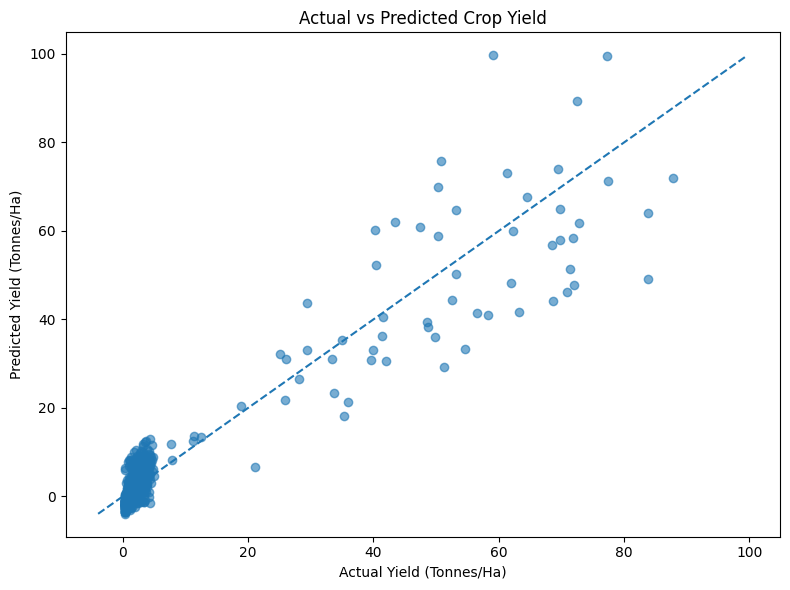

In [65]:
# ============================================================
# 14.7 Actual vs Predicted Yield Visualization
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield (Tonnes/Ha)")
plt.ylabel("Predicted Yield (Tonnes/Ha)")
plt.title("Actual vs Predicted Crop Yield")
plt.tight_layout()
plt.show()

### Actual vs Predicted Yield Plot

The scatter plot compares observed yield values with the values predicted by the multiple linear regression model.

Points closer to the diagonal reference line indicate more accurate predictions. The overall concentration of observations around the reference line supports the strong predictive performance indicated by the R-squared value.

In [66]:
# ============================================================
# 14.8 Residual Analysis
# ============================================================

residuals = y_test - y_pred

residual_summary = pd.DataFrame({
    "Residual_Mean": [residuals.mean()],
    "Residual_Std": [residuals.std()],
    "Residual_Min": [residuals.min()],
    "Residual_Max": [residuals.max()]
})

residual_summary = residual_summary.round(4)

print("Residual Analysis")
print("-" * 50)

residual_summary

Residual Analysis
--------------------------------------------------


,Residual_Mean,Residual_Std,Residual_Min,Residual_Max
0,-0.0702,4.8204,-40.6397,34.6095


### Residual Analysis

Residuals represent the difference between actual and predicted yield values.

Residual analysis is used to examine the magnitude and distribution of prediction errors. A residual mean close to zero indicates that the model does not show substantial systematic overprediction or underprediction.

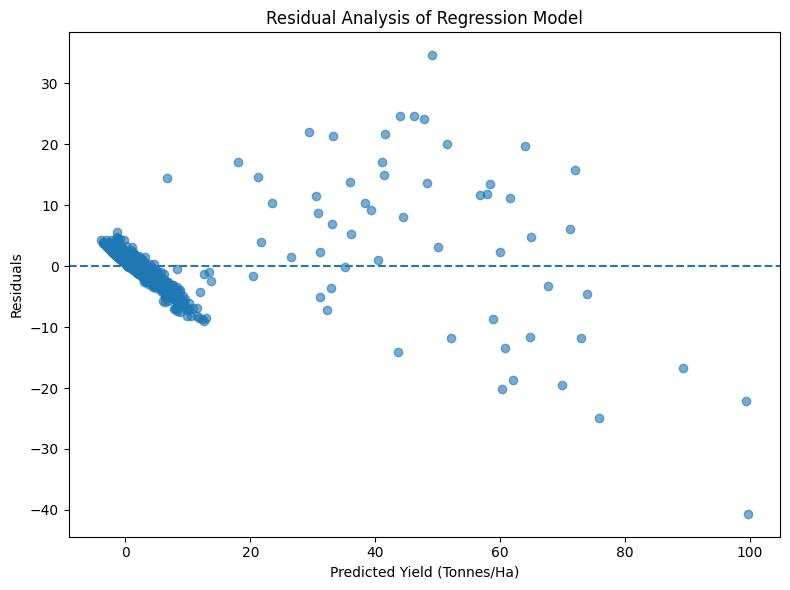

In [67]:
# ============================================================
# 14.9 Residual Plot
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield (Tonnes/Ha)")
plt.ylabel("Residuals")
plt.title("Residual Analysis of Regression Model")
plt.tight_layout()
plt.show()

### Residual Plot

The residual plot shows the prediction errors against the predicted yield values.

A random distribution of residuals around the zero reference line indicates that the model does not exhibit an obvious systematic pattern in its prediction errors.

In [68]:
# ============================================================
# 14.10 Regression Model Summary
# ============================================================

regression_summary = pd.DataFrame({
    "Metric": [
        "Training Observations",
        "Testing Observations",
        "Number of Features",
        "R-squared",
        "Adjusted R-squared",
        "Mean Absolute Error",
        "Mean Squared Error",
        "Root Mean Squared Error",
        "Intercept"
    ],
    "Value": [
        len(X_train),
        len(X_test),
        X_train.shape[1],
        r2,
        adjusted_r2,
        mae,
        mse,
        rmse,
        linear_model.intercept_
    ]
})

regression_summary["Value"] = regression_summary["Value"].round(4)

print("Regression Model Summary")
print("-" * 50)

regression_summary

Regression Model Summary
--------------------------------------------------


,Metric,Value
0,Training Observations,3200.0000
1,Testing Observations,800.0000
2,Number of Features,7.0000
3,R-squared,0.8796
4,Adjusted R-squared,0.8785
5,Mean Absolute Error,2.8046
6,Mean Squared Error,23.2118
7,Root Mean Squared Error,4.8179
8,Intercept,-3.8552


### Regression Model Summary

The multiple linear regression model uses seven agricultural and environmental variables to estimate crop yield.

The model is evaluated using R-squared, adjusted R-squared, MAE, MSE, and RMSE. These metrics collectively describe the explanatory power and prediction error of the fitted model.

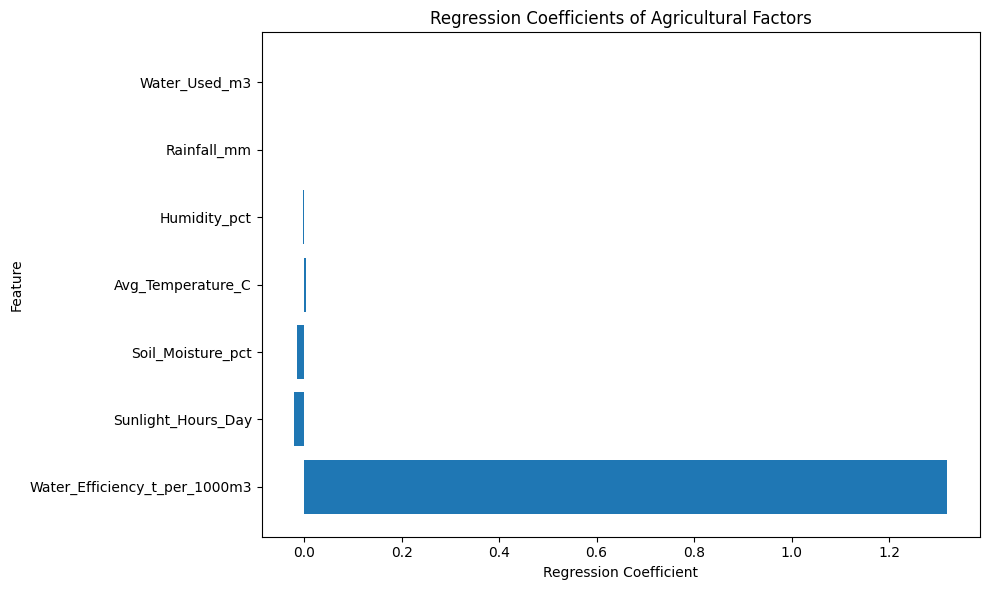

In [69]:
# ============================================================
# 14.11 Regression Coefficient Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    coefficient_summary["Feature"],
    coefficient_summary["Coefficient"]
)

plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("Regression Coefficients of Agricultural Factors")
plt.tight_layout()
plt.show()

### Regression Coefficient Visualization

The coefficient plot presents the direction and magnitude of the estimated relationships between the explanatory variables and crop yield.

Positive coefficients indicate positive associations with predicted yield, while negative coefficients indicate negative associations, holding the other variables constant.

# 15. Key Findings and Insights

The analysis of the seasonal agricultural performance dataset provides several important findings.

1. **Seasonal variation:**  
   The One-Way ANOVA did not identify a statistically significant difference in mean yield across Kharif, Rabi, and Zaid seasons at the 5% significance level. However, the Kruskal-Wallis test identified statistically significant differences, providing a useful non-parametric validation of seasonal variation.

2. **Crop-wise variation:**  
   Both One-Way ANOVA and Kruskal-Wallis testing identified statistically significant differences in yield across crop types. Therefore, crop type is strongly associated with variation in agricultural yield.

3. **Water efficiency and yield:**  
   Water Efficiency has a strong positive correlation with yield, with a Pearson correlation of approximately 0.913. This indicates a strong linear association between efficient water utilization and agricultural productivity.

4. **Yield and profit:**  
   Yield and profit show a positive correlation of approximately 0.488, indicating that higher agricultural yield is generally associated with higher profit.

5. **Water usage and yield:**  
   Water Used shows a moderate positive correlation with yield of approximately 0.386.

6. **Regression performance:**  
   The multiple linear regression model achieves an R-squared value of approximately 0.8796 and an adjusted R-squared value of approximately 0.8785, indicating strong explanatory performance.

7. **Prediction error:**  
   The regression model produces an MAE of approximately 2.8046 and an RMSE of approximately 4.8179, providing an estimate of the typical prediction error.

8. **Regression coefficients:**  
   The regression coefficients provide information about the direction and magnitude of the relationship between environmental and water-management variables and crop yield.

# 16. Conclusion

This project analyzed seasonal agricultural performance using statistical analysis, data visualization, correlation analysis, hypothesis testing, and multiple linear regression.

The analysis demonstrated that agricultural performance is influenced by several interacting environmental, water-management, and crop-related factors. Crop type showed statistically significant differences in yield, while the seasonal analysis produced different results under parametric and non-parametric testing.

Correlation analysis identified a particularly strong positive relationship between water efficiency and crop yield. Yield was also positively associated with water usage and profit.

The multiple linear regression model demonstrated strong predictive and explanatory performance, achieving an R-squared value of approximately 0.8796. The model therefore provides a useful analytical approach for understanding the relationship between agricultural conditions and crop yield.

Overall, the findings demonstrate the usefulness of data analytics and statistical modelling for identifying agricultural patterns, evaluating resource utilization, understanding crop-wise differences, and supporting data-driven agricultural decision-making.

# 17. Limitations

1. The analysis is based on the variables available in the provided dataset.

2. Correlation and regression analysis identify statistical associations and should not automatically be interpreted as proof of causation.

3. The regression model is based on the selected environmental and water-management variables and may not capture all real-world agricultural factors.

4. Factors such as market prices, fertilizer usage, crop variety, pest management, farming technology, and farm-level management practices may also influence agricultural outcomes but are not included in the regression model.

5. The statistical conclusions are specific to the observations represented in the dataset.

# 18. Final Project Summary

The Seasonal Agriculture Performance Analysis project successfully applies a complete data analytics workflow to agricultural data.

The workflow includes:

- Dataset inspection and data preparation
- Descriptive statistical analysis
- Seasonal analysis
- Crop-wise yield analysis
- Correlation analysis
- Statistical significance testing
- One-Way ANOVA
- Kruskal-Wallis validation
- Multiple linear regression
- Model performance evaluation
- Regression coefficient analysis
- Actual versus predicted analysis
- Residual analysis
- Data visualization
- Interpretation of agricultural insights

The analysis provides a structured understanding of agricultural performance and demonstrates how statistical and machine-learning techniques can be used to extract meaningful insights from agricultural datasets.